# 🔬 t-SNE Dimensionality Reduction: Pros, Cons & Deep Dive

**t-SNE (t-distributed Stochastic Neighbor Embedding)** is one of the most powerful tools for visualising high-dimensional data — but it comes with significant caveats.

This notebook walks through:
1. **What t-SNE is and how it works**
2. **Pros**: Where t-SNE shines
3. **Cons**: Where t-SNE misleads you
4. **Hyperparameter sensitivity**: Perplexity, iterations, learning rate
5. **Comparison with PCA and UMAP**
6. **Practical guidelines**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits, make_blobs, make_swiss_roll
from sklearn.preprocessing import StandardScaler
import warnings
import time
warnings.filterwarnings('ignore')

# Consistent style
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#333355',
    'axes.labelcolor': '#ccccee',
    'xtick.color': '#888899',
    'ytick.color': '#888899',
    'text.color': '#ccccee',
    'grid.color': '#222244',
    'grid.linestyle': '--',
    'grid.alpha': 0.4,
    'font.family': 'monospace'
})

PALETTE = ['#ff6b9d','#c77dff','#48cae4','#80ffdb','#ffd166','#ff8c42']
np.random.seed(42)
print('✅ Setup complete. Ready to explore t-SNE!')

✅ Setup complete. Ready to explore t-SNE!


---
## 1. How t-SNE Works (Intuition)

t-SNE minimises the **KL divergence** between two probability distributions:
- **High-dimensional space**: Gaussian kernel — `P(j|i)` = similarity between points i and j
- **Low-dimensional space**: Student t-distribution (heavy tails) — `Q(j|i)`

The heavy-tailed t-distribution in the low-dim space counteracts the "crowding problem" and allows clusters to separate clearly.

$$C = \sum_i KL(P_i || Q_i) = \sum_i \sum_j p_{j|i} \log \frac{p_{j|i}}{q_{j|i}}$$

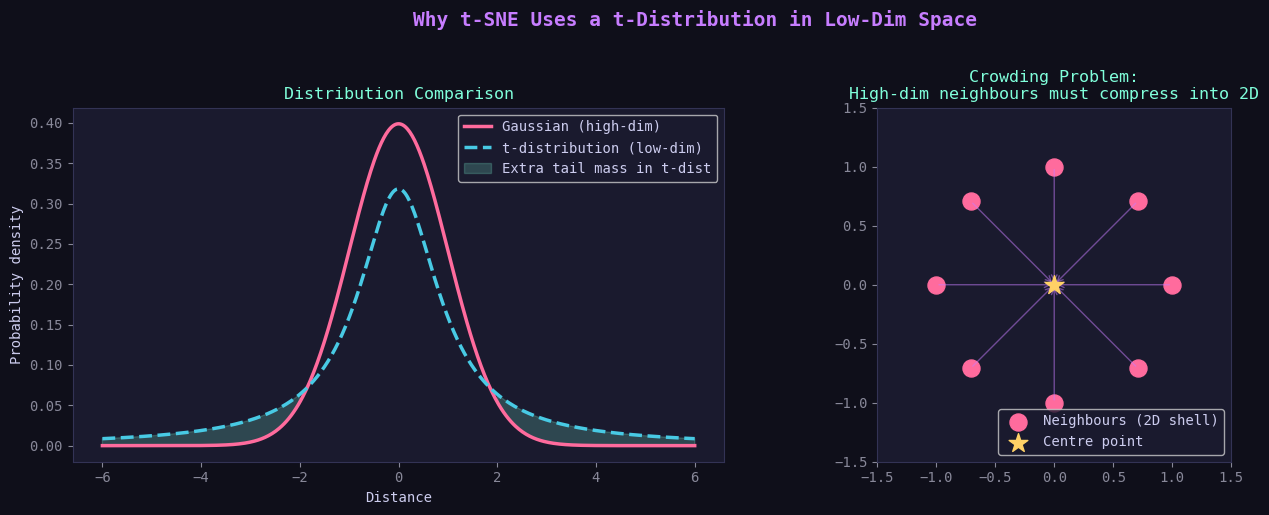

👆 The t-distribution's heavier tails help moderate distances expand, solving the crowding problem


In [2]:
# Visualise the Gaussian vs t-distribution tail difference
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Why t-SNE Uses a t-Distribution in Low-Dim Space', fontsize=14, fontweight='bold', color='#c77dff', y=1.02)

x = np.linspace(-6, 6, 500)
gaussian = np.exp(-x**2 / 2) / np.sqrt(2 * np.pi)
t_dist = (1 + x**2)**(-1) / np.pi  # t with 1 degree of freedom

ax = axes[0]
ax.plot(x, gaussian, color='#ff6b9d', lw=2.5, label='Gaussian (high-dim)')
ax.plot(x, t_dist, color='#48cae4', lw=2.5, label='t-distribution (low-dim)', linestyle='--')
ax.fill_between(x, t_dist, gaussian, where=(np.abs(x) > 2), alpha=0.2, color='#80ffdb', label='Extra tail mass in t-dist')
ax.set_title('Distribution Comparison', color='#80ffdb')
ax.legend()
ax.set_xlabel('Distance')
ax.set_ylabel('Probability density')

# Show the crowding problem concept
ax2 = axes[1]
angles_2d = np.linspace(0, 2*np.pi, 8, endpoint=False)
ring_2d = np.column_stack([np.cos(angles_2d), np.sin(angles_2d)])
center_2d = np.array([[0, 0]])

ax2.scatter(ring_2d[:, 0], ring_2d[:, 1], c='#ff6b9d', s=150, zorder=3, label='Neighbours (2D shell)')
ax2.scatter(center_2d[:, 0], center_2d[:, 1], c='#ffd166', s=200, zorder=4, label='Centre point', marker='*')
for pt in ring_2d:
    ax2.annotate('', xy=center_2d[0], xytext=pt,
                arrowprops=dict(arrowstyle='->', color='#c77dff', alpha=0.5))
ax2.set_title('Crowding Problem:\nHigh-dim neighbours must compress into 2D', color='#80ffdb')
ax2.legend(loc='lower right')
ax2.set_aspect('equal')
ax2.set_xlim(-1.5, 1.5); ax2.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()
print('👆 The t-distribution\'s heavier tails help moderate distances expand, solving the crowding problem')

---
## ✅ PRO 1: Exceptional Cluster Separation on Real Data

t-SNE excels at revealing cluster structure that linear methods like PCA miss entirely.

In [3]:
# Load digits dataset (64-dimensional)
digits = load_digits()
X, y = digits.data, digits.target
X_scaled = StandardScaler().fit_transform(X)

print(f'Dataset: {X.shape[0]} samples × {X.shape[1]} features → 10 digit classes')
print('Running PCA and t-SNE...')

# PCA
t0 = time.time()
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_time = time.time() - t0

# t-SNE
t0 = time.time()
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
tsne_time = time.time() - t0

print(f'PCA time:   {pca_time:.2f}s')
print(f't-SNE time: {tsne_time:.2f}s  ({tsne_time/pca_time:.0f}× slower)')

Dataset: 1797 samples × 64 features → 10 digit classes
Running PCA and t-SNE...
PCA time:   0.04s
t-SNE time: 8.62s  (194× slower)


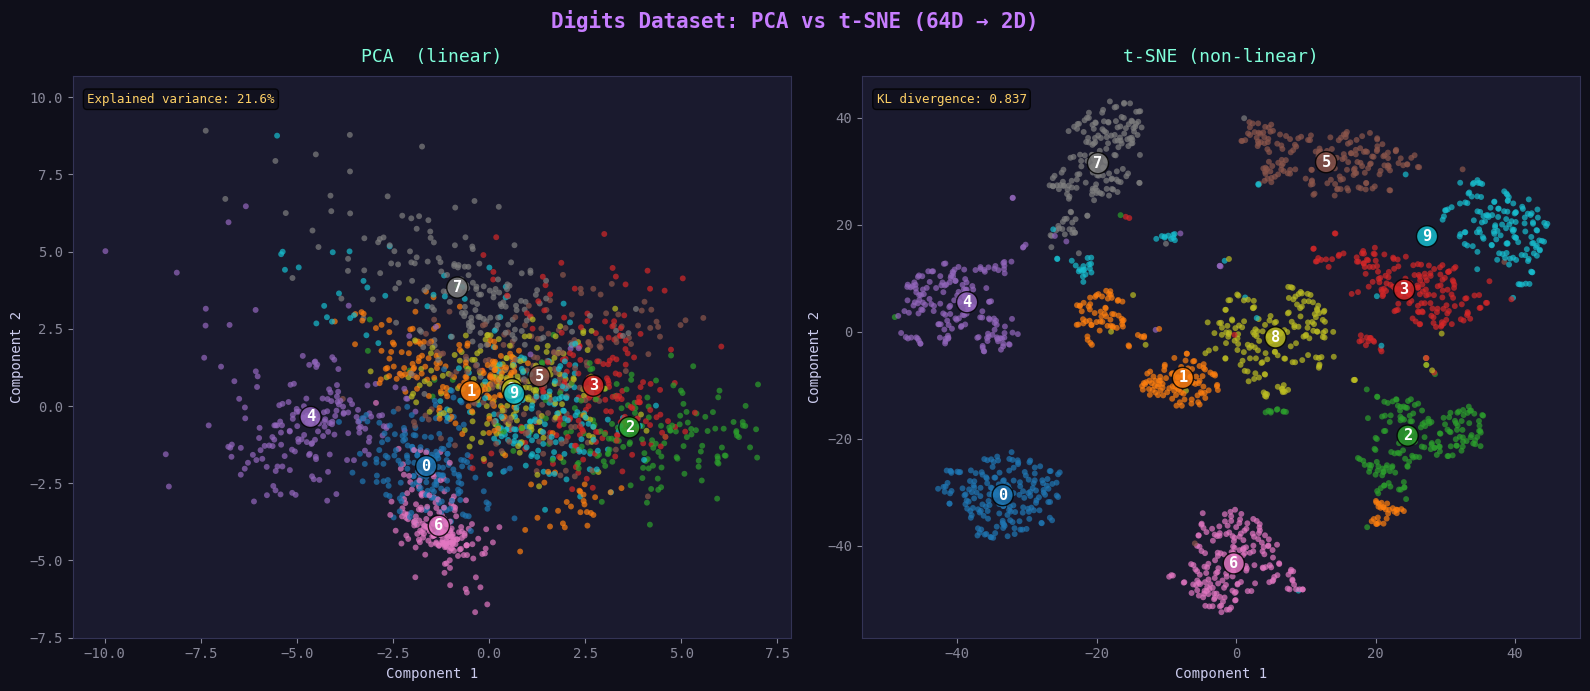

✅ PRO: t-SNE creates beautifully separated clusters — similar digits group together


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Digits Dataset: PCA vs t-SNE (64D → 2D)', fontsize=15, fontweight='bold', color='#c77dff')

cmap = plt.cm.get_cmap('tab10')

for ax, (X_2d, title, note) in zip(axes, [
    (X_pca,  'PCA  (linear)',  f'Explained variance: {pca.explained_variance_ratio_.sum():.1%}'),
    (X_tsne, 't-SNE (non-linear)', f'KL divergence: {tsne.kl_divergence_:.3f}')
]):
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1],
                        c=y, cmap='tab10', alpha=0.7, s=18, linewidths=0)
    ax.set_title(title, fontsize=13, color='#80ffdb', pad=10)
    ax.set_xlabel('Component 1'); ax.set_ylabel('Component 2')
    ax.text(0.02, 0.97, note, transform=ax.transAxes,
            fontsize=9, color='#ffd166', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#0f0f1a', alpha=0.8))
    # Add digit labels at cluster centroids
    for digit in range(10):
        mask = y == digit
        cx, cy = X_2d[mask, 0].mean(), X_2d[mask, 1].mean()
        ax.text(cx, cy, str(digit), fontsize=11, fontweight='bold',
                color='white', ha='center', va='center',
                bbox=dict(boxstyle='circle,pad=0.2', facecolor=cmap(digit/10), alpha=0.85))

plt.tight_layout()
plt.show()
print('✅ PRO: t-SNE creates beautifully separated clusters — similar digits group together')

---
## ✅ PRO 2: Reveals Non-Linear Structure

t-SNE unrolls manifolds that PCA cannot separate.

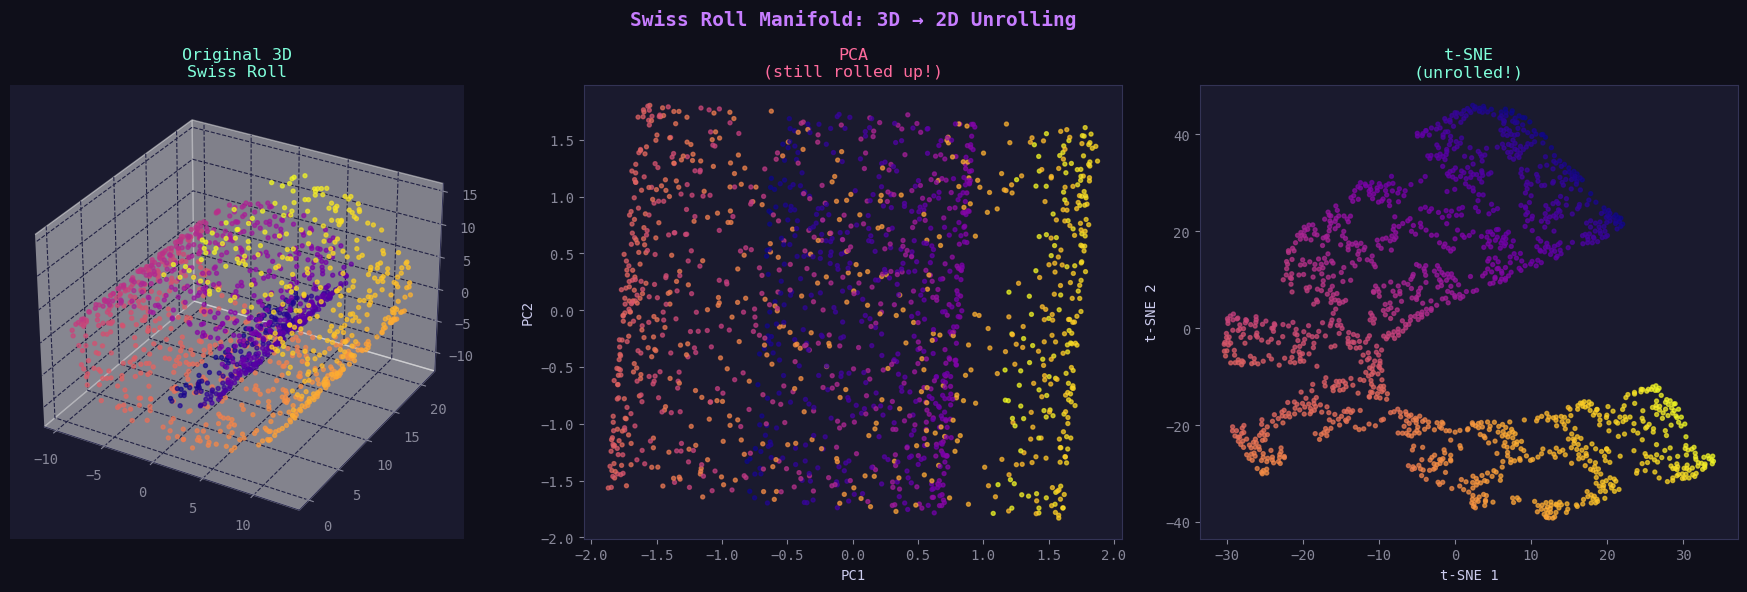

✅ PRO: t-SNE successfully unrolls non-linear manifolds that PCA cannot handle


In [5]:
# Swiss Roll — a classic non-linear manifold
X_roll, color_roll = make_swiss_roll(n_samples=1500, noise=0.1, random_state=42)
X_roll_scaled = StandardScaler().fit_transform(X_roll)

X_roll_pca  = PCA(n_components=2).fit_transform(X_roll_scaled)
X_roll_tsne = TSNE(n_components=2, perplexity=40, max_iter=1000, random_state=42).fit_transform(X_roll_scaled)

fig = plt.figure(figsize=(18, 6))
fig.suptitle('Swiss Roll Manifold: 3D → 2D Unrolling', fontsize=14, fontweight='bold', color='#c77dff')

# 3D original
ax1 = fig.add_subplot(131, projection='3d')
ax1.set_facecolor('#1a1a2e')
ax1.scatter(X_roll[:, 0], X_roll[:, 1], X_roll[:, 2], c=color_roll, cmap='plasma', s=8, alpha=0.7)
ax1.set_title('Original 3D\nSwiss Roll', color='#80ffdb')
ax1.tick_params(colors='#888899')

ax2 = fig.add_subplot(132)
ax2.scatter(X_roll_pca[:, 0], X_roll_pca[:, 1], c=color_roll, cmap='plasma', s=8, alpha=0.7)
ax2.set_title('PCA\n(still rolled up!)', color='#ff6b9d')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')

ax3 = fig.add_subplot(133)
ax3.scatter(X_roll_tsne[:, 0], X_roll_tsne[:, 1], c=color_roll, cmap='plasma', s=8, alpha=0.7)
ax3.set_title('t-SNE\n(unrolled!)', color='#80ffdb')
ax3.set_xlabel('t-SNE 1'); ax3.set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()
print('✅ PRO: t-SNE successfully unrolls non-linear manifolds that PCA cannot handle')

---
## ❌ CON 1: Global Structure is NOT Preserved

**This is the #1 misinterpretation of t-SNE.** Distances *between* clusters are meaningless — only local neighbourhood structure is preserved.

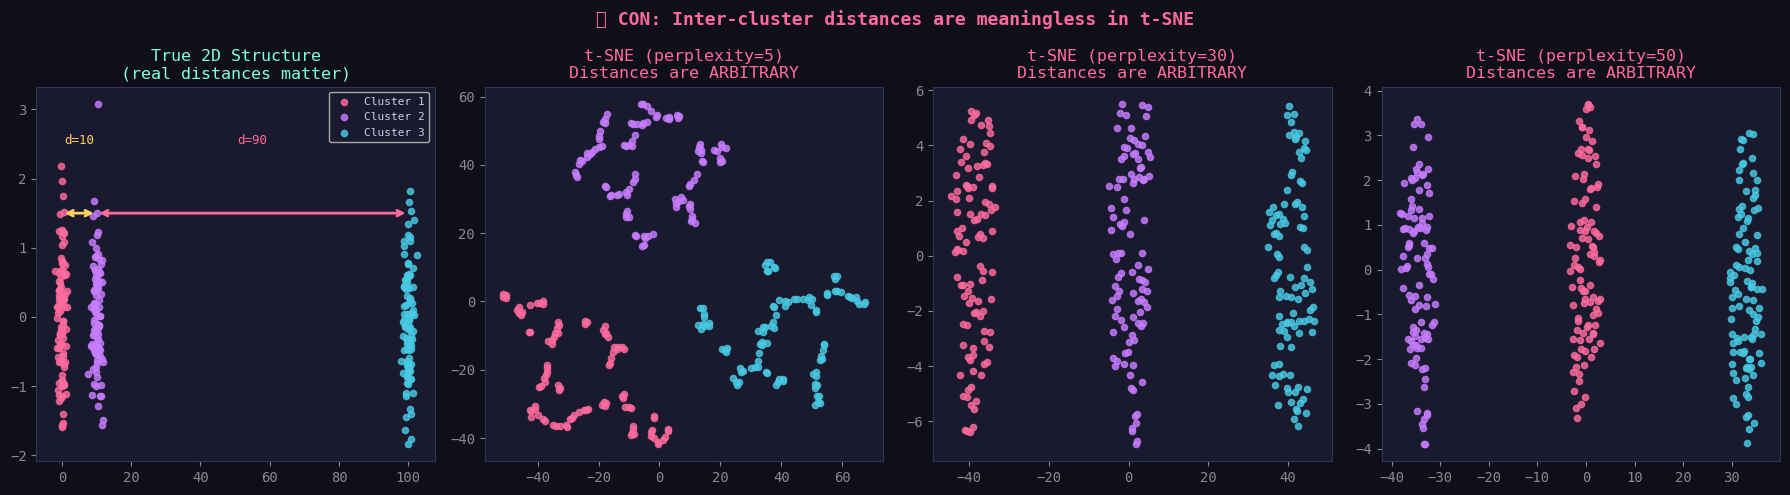

⚠️  The clusters that were 10x further apart look equally spaced — or even reversed!
⚠️  Never interpret inter-cluster distances in a t-SNE plot


In [6]:
# Create data with known inter-cluster distances
centers = np.array([[0, 0], [10, 0], [100, 0]])  # Clusters far apart in reality
X_dist, y_dist = make_blobs(n_samples=300, centers=centers, cluster_std=0.8, random_state=42)

# Show how different perplexity values distort global distances
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('❌ CON: Inter-cluster distances are meaningless in t-SNE', fontsize=13, fontweight='bold', color='#ff6b9d')

# Original
ax = axes[0]
for i, c in enumerate(PALETTE[:3]):
    mask = y_dist == i
    ax.scatter(X_dist[mask, 0], X_dist[mask, 1], c=c, s=20, alpha=0.8,
               label=f'Cluster {i+1}')
ax.set_title('True 2D Structure\n(real distances matter)', color='#80ffdb')
ax.annotate('', xy=(10, 1.5), xytext=(0, 1.5),
            arrowprops=dict(arrowstyle='<->', color='#ffd166', lw=2))
ax.text(5, 2.5, 'd=10', ha='center', color='#ffd166', fontsize=9)
ax.annotate('', xy=(100, 1.5), xytext=(10, 1.5),
            arrowprops=dict(arrowstyle='<->', color='#ff6b9d', lw=2))
ax.text(55, 2.5, 'd=90', ha='center', color='#ff6b9d', fontsize=9)
ax.legend(fontsize=8)

for ax, perp in zip(axes[1:], [5, 30, 50]):
    tsne_temp = TSNE(n_components=2, perplexity=perp, max_iter=1000, random_state=42)
    X_t = tsne_temp.fit_transform(X_dist)
    for i, c in enumerate(PALETTE[:3]):
        mask = y_dist == i
        ax.scatter(X_t[mask, 0], X_t[mask, 1], c=c, s=20, alpha=0.8)
    ax.set_title(f't-SNE (perplexity={perp})\nDistances are ARBITRARY', color='#ff6b9d')

plt.tight_layout()
plt.show()
print('⚠️  The clusters that were 10x further apart look equally spaced — or even reversed!')
print('⚠️  Never interpret inter-cluster distances in a t-SNE plot')

---
## ❌ CON 2: Sensitive to Hyperparameters — Especially Perplexity

The same data can look completely different with different perplexity values.

In [7]:
# Show perplexity effect on digits data (subset for speed)
subset = 500
idx = np.random.choice(len(X_scaled), subset, replace=False)
Xs, ys = X_scaled[idx], y[idx]

perplexities = [2, 5, 20, 50, 100, 200]
results = {}
print('Running t-SNE with different perplexities...')
for p in perplexities:
    t0 = time.time()
    results[p] = TSNE(n_components=2, perplexity=p, max_iter=1000, random_state=42).fit_transform(Xs)
    print(f'  perplexity={p:>4}: {time.time()-t0:.1f}s')
print('Done!')

Running t-SNE with different perplexities...
  perplexity=   2: 1.3s
  perplexity=   5: 1.1s
  perplexity=  20: 1.3s
  perplexity=  50: 1.6s
  perplexity= 100: 2.3s
  perplexity= 200: 3.2s
Done!


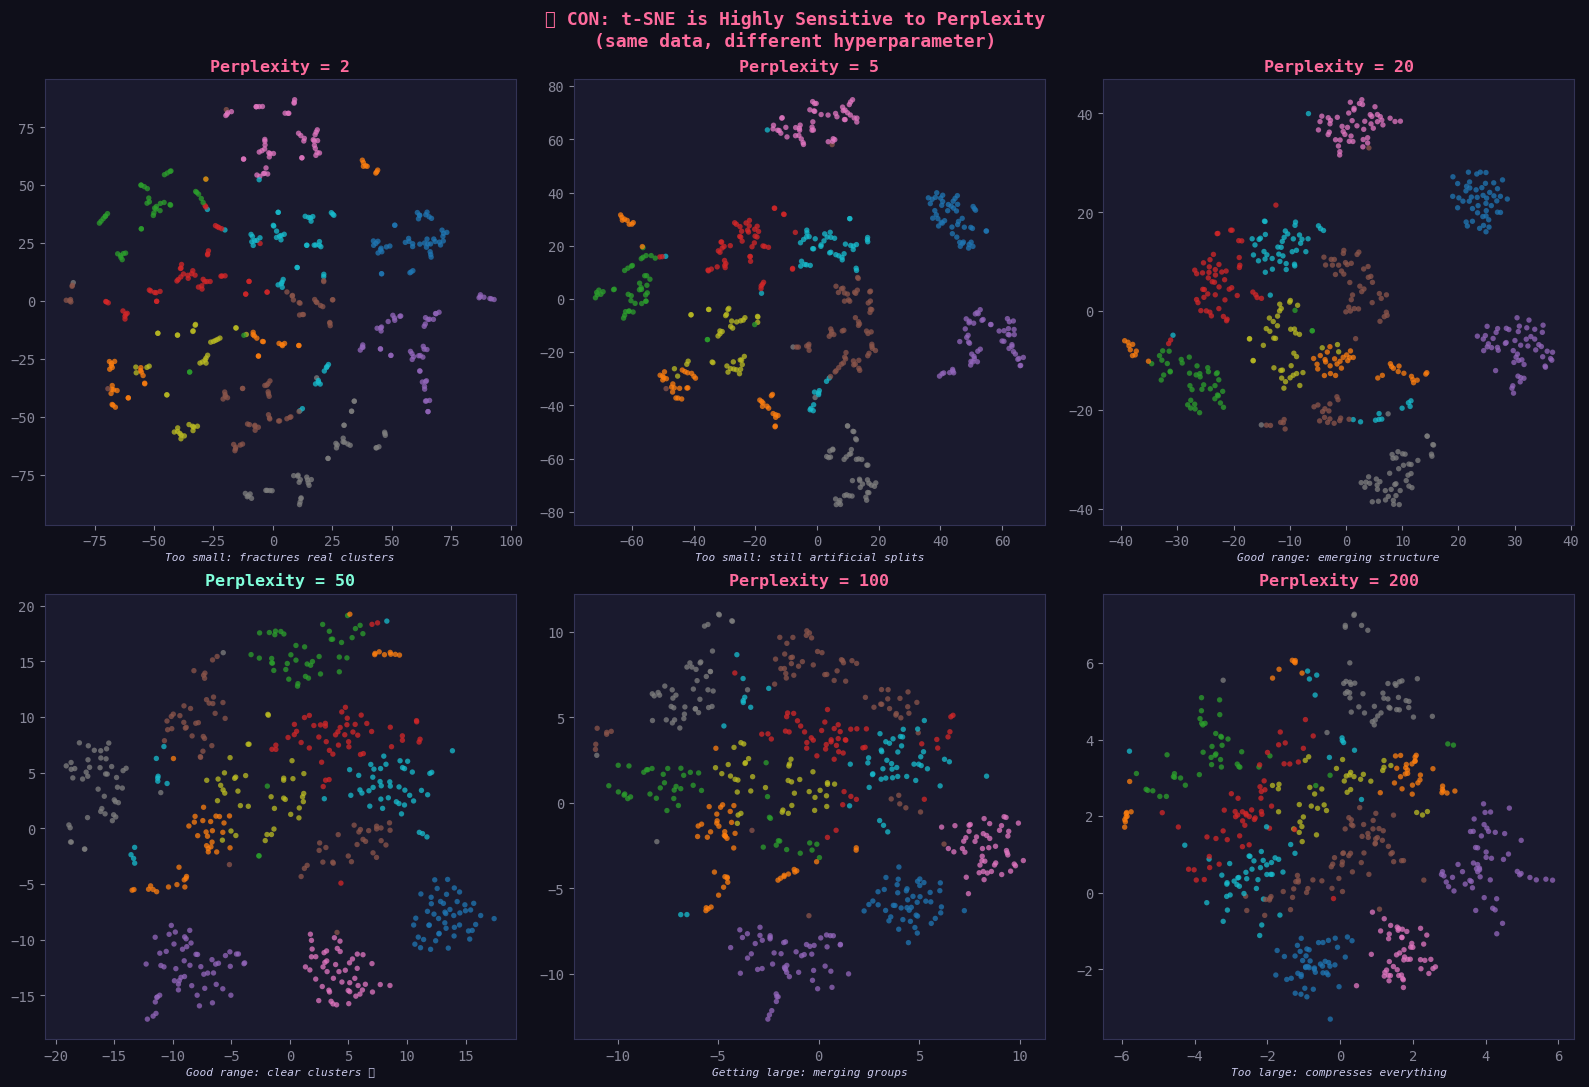

Rule of thumb: perplexity should be between 5 and 50; √n is a reasonable starting point


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 11))
fig.suptitle('❌ CON: t-SNE is Highly Sensitive to Perplexity\n(same data, different hyperparameter)', 
             fontsize=13, fontweight='bold', color='#ff6b9d')

interpretations = [
    'Too small: fractures real clusters',
    'Too small: still artificial splits',
    'Good range: emerging structure',
    'Good range: clear clusters ✅',
    'Getting large: merging groups',
    'Too large: compresses everything'
]

for ax, (p, interp) in zip(axes.flat, zip(perplexities, interpretations)):
    X_2d = results[p]
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=ys, cmap='tab10', 
                         alpha=0.75, s=15, linewidths=0)
    good = '✅' in interp
    color = '#80ffdb' if good else '#ff6b9d'
    ax.set_title(f'Perplexity = {p}', color=color, fontsize=12, fontweight='bold')
    ax.text(0.5, -0.08, interp, transform=ax.transAxes,
            ha='center', fontsize=8, color='#ccccee',
            style='italic')

plt.tight_layout()
plt.show()
print('Rule of thumb: perplexity should be between 5 and 50; √n is a reasonable starting point')

---
## ❌ CON 3: Non-Deterministic & Non-Reproducible

t-SNE uses gradient descent with random initialisation. Two runs can produce structurally different (but equally valid) embeddings.

Running 4 t-SNE embeddings with different random seeds...
  seed=0: done
  seed=1: done
  seed=2: done
  seed=99: done


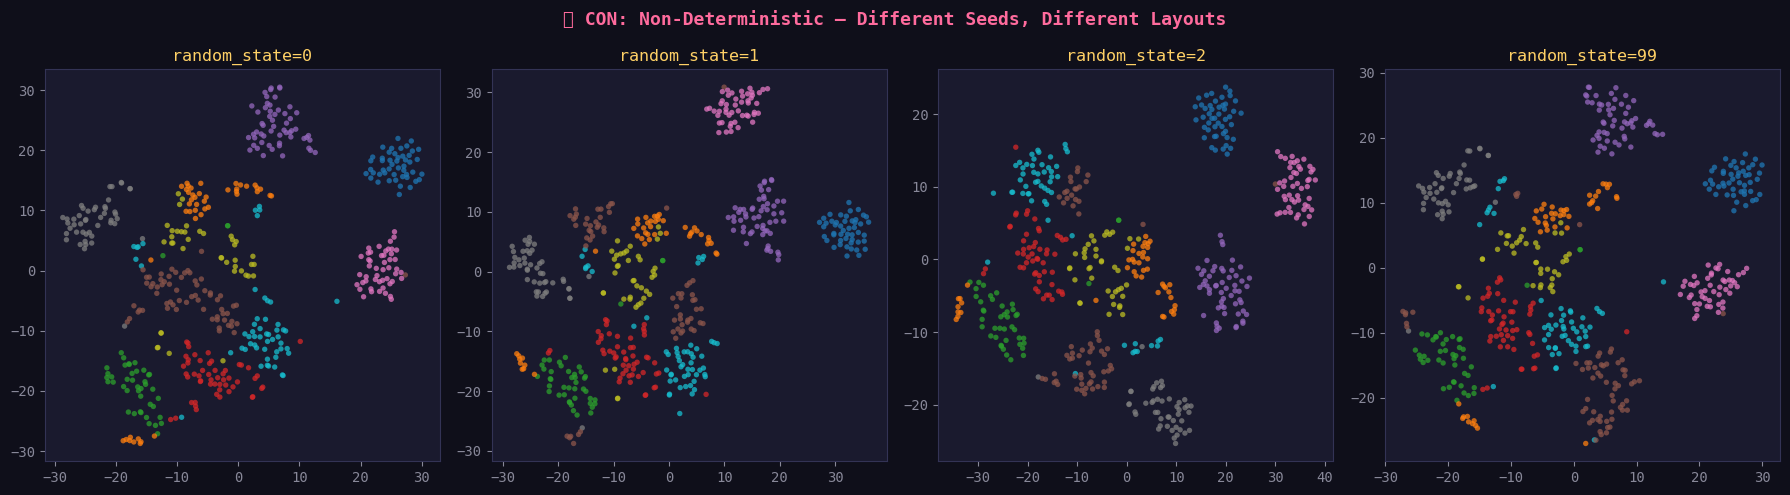

⚠️  Cluster positions, orientations, and even apparent cluster counts can shift between runs!
✅  Always set random_state for reproducibility, and run multiple times to verify structure.


In [9]:
print('Running 4 t-SNE embeddings with different random seeds...')
seeds = [0, 1, 2, 99]
tsne_runs = []
for seed in seeds:
    emb = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=seed).fit_transform(Xs)
    tsne_runs.append(emb)
    print(f'  seed={seed}: done')

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('❌ CON: Non-Deterministic — Different Seeds, Different Layouts',
             fontsize=13, fontweight='bold', color='#ff6b9d')

for ax, (emb, seed) in zip(axes, zip(tsne_runs, seeds)):
    ax.scatter(emb[:, 0], emb[:, 1], c=ys, cmap='tab10', alpha=0.75, s=15, linewidths=0)
    ax.set_title(f'random_state={seed}', color='#ffd166')

plt.tight_layout()
plt.show()
print('⚠️  Cluster positions, orientations, and even apparent cluster counts can shift between runs!')
print('✅  Always set random_state for reproducibility, and run multiple times to verify structure.')

---
## ❌ CON 4: Computational Cost — O(n²) Naive, O(n log n) with Barnes-Hut

t-SNE is significantly slower than PCA and can be infeasible for large datasets.

Benchmarking PCA vs t-SNE at different sample sizes...
  n=  100: PCA=0.011s  t-SNE=0.28s  (ratio: 26×)
  n=  300: PCA=0.020s  t-SNE=0.51s  (ratio: 26×)
  n=  500: PCA=0.002s  t-SNE=0.98s  (ratio: 488×)
  n=  800: PCA=0.002s  t-SNE=1.54s  (ratio: 730×)
  n= 1200: PCA=0.003s  t-SNE=2.76s  (ratio: 920×)
  n= 1800: PCA=0.003s  t-SNE=4.57s  (ratio: 1529×)


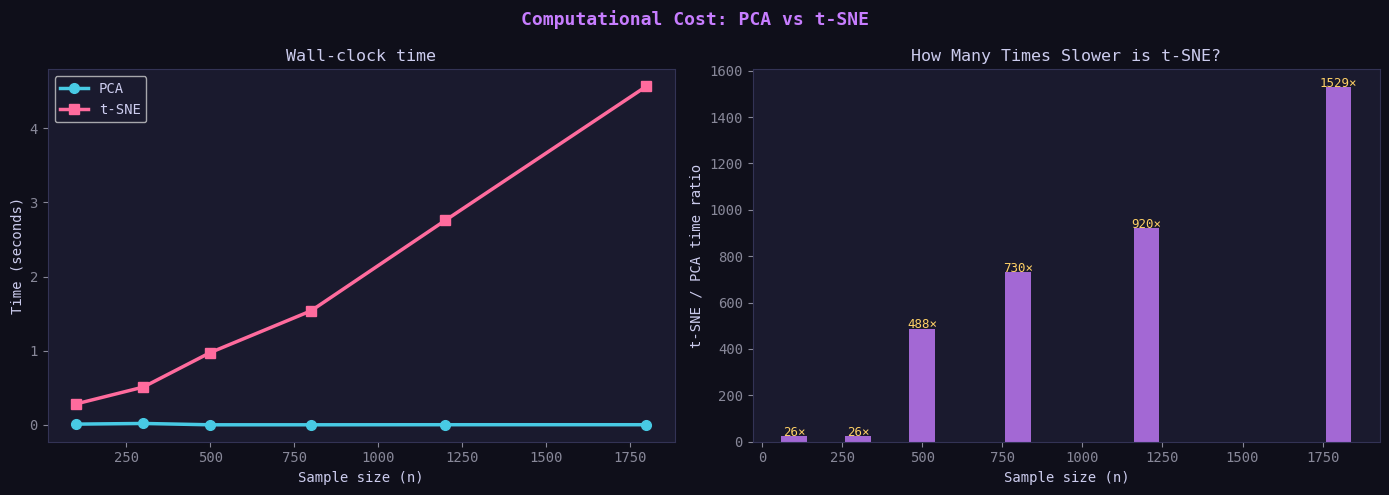

In [10]:
sample_sizes = [100, 300, 500, 800, 1200, 1800]
pca_times, tsne_times = [], []

print('Benchmarking PCA vs t-SNE at different sample sizes...')
for n in sample_sizes:
    X_bench = np.random.randn(n, 50)
    
    t0 = time.time()
    PCA(n_components=2).fit_transform(X_bench)
    pca_times.append(time.time() - t0)
    
    t0 = time.time()
    TSNE(n_components=2, perplexity=30, max_iter=500, random_state=42).fit_transform(X_bench)
    tsne_times.append(time.time() - t0)
    print(f'  n={n:>5}: PCA={pca_times[-1]:.3f}s  t-SNE={tsne_times[-1]:.2f}s  (ratio: {tsne_times[-1]/pca_times[-1]:.0f}×)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Computational Cost: PCA vs t-SNE', fontsize=13, fontweight='bold', color='#c77dff')

ax = axes[0]
ax.plot(sample_sizes, pca_times,  'o-', color='#48cae4', lw=2.5, label='PCA', markersize=7)
ax.plot(sample_sizes, tsne_times, 's-', color='#ff6b9d', lw=2.5, label='t-SNE', markersize=7)
ax.set_xlabel('Sample size (n)'); ax.set_ylabel('Time (seconds)')
ax.set_title('Wall-clock time')
ax.legend()

ax2 = axes[1]
ratios = [t/p for t, p in zip(tsne_times, pca_times)]
bars = ax2.bar(sample_sizes, ratios, color='#c77dff', alpha=0.8, width=80)
ax2.set_xlabel('Sample size (n)'); ax2.set_ylabel('t-SNE / PCA time ratio')
ax2.set_title('How Many Times Slower is t-SNE?')
for bar, ratio in zip(bars, ratios):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{ratio:.0f}×', ha='center', fontsize=9, color='#ffd166')

plt.tight_layout()
plt.show()

---
## ❌ CON 5: Cannot Embed New Points (No Out-of-Sample Extension)

Unlike PCA, t-SNE has no `transform()` method. You must re-run the full algorithm on the entire dataset to include new points.

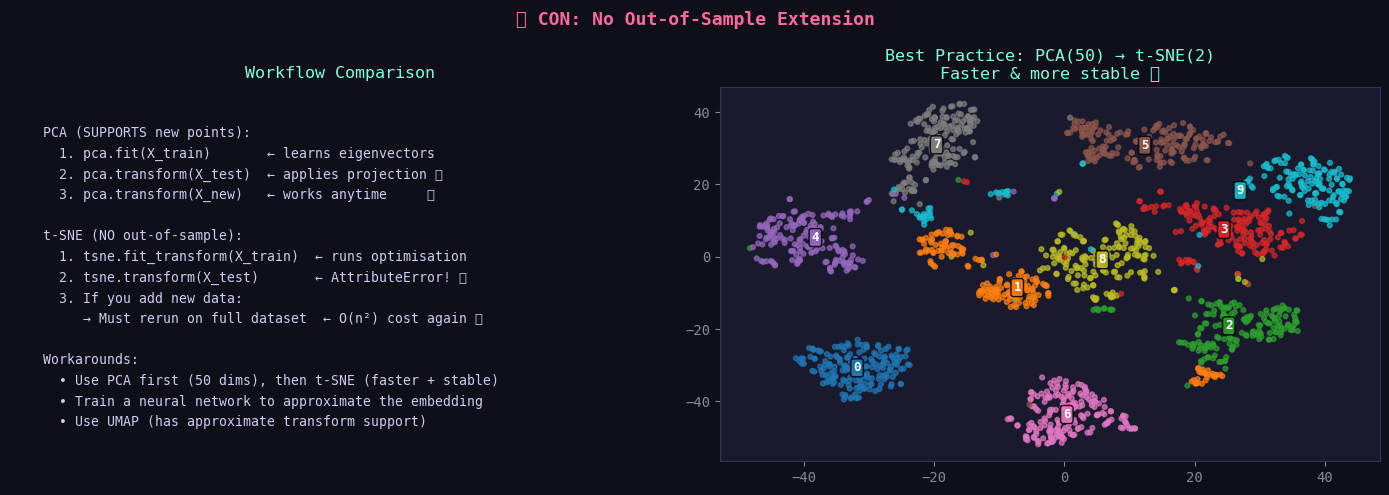

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('❌ CON: No Out-of-Sample Extension', fontsize=13, fontweight='bold', color='#ff6b9d')

workflow_text = """
PCA (SUPPORTS new points):
  1. pca.fit(X_train)       ← learns eigenvectors
  2. pca.transform(X_test)  ← applies projection ✅
  3. pca.transform(X_new)   ← works anytime     ✅

t-SNE (NO out-of-sample):
  1. tsne.fit_transform(X_train)  ← runs optimisation
  2. tsne.transform(X_test)       ← AttributeError! ❌
  3. If you add new data:
     → Must rerun on full dataset  ← O(n²) cost again ❌

Workarounds:
  • Use PCA first (50 dims), then t-SNE (faster + stable)
  • Train a neural network to approximate the embedding
  • Use UMAP (has approximate transform support)
"""

axes[0].text(0.05, 0.95, workflow_text, transform=axes[0].transAxes,
             va='top', fontsize=9.5, family='monospace',
             color='#ccccee', linespacing=1.6)
axes[0].set_title('Workflow Comparison', color='#80ffdb')
axes[0].axis('off')

# Demonstrate the PCA trick
pca_50 = PCA(n_components=min(50, X_scaled.shape[1]))
X_pca50 = pca_50.fit_transform(X_scaled)
X_pca_tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42).fit_transform(X_pca50)

axes[1].scatter(X_pca_tsne[:, 0], X_pca_tsne[:, 1], c=y, cmap='tab10', alpha=0.7, s=12)
for digit in range(10):
    mask = y == digit
    cx, cy = X_pca_tsne[mask, 0].mean(), X_pca_tsne[mask, 1].mean()
    axes[1].text(cx, cy, str(digit), fontsize=9, fontweight='bold',
                 color='white', ha='center', va='center',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor=plt.cm.tab10(digit/10), alpha=0.9))
axes[1].set_title('Best Practice: PCA(50) → t-SNE(2)\nFaster & more stable ✅', color='#80ffdb')

plt.tight_layout()
plt.show()

---
## 📊 Final Comparison: t-SNE vs PCA vs UMAP

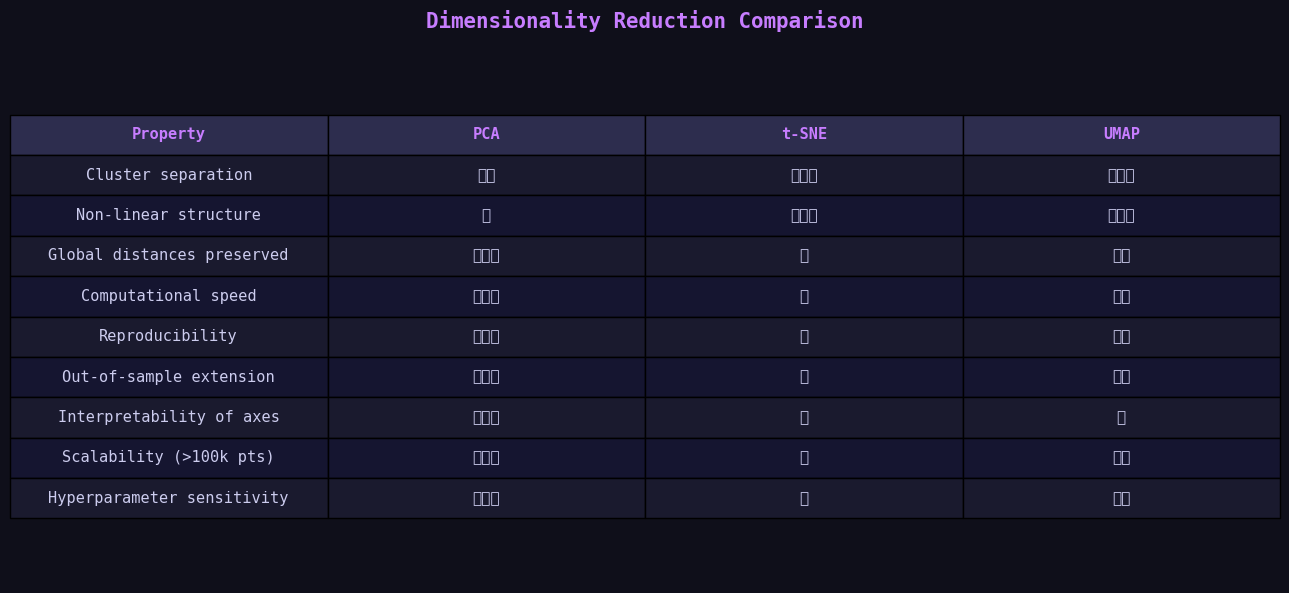

In [12]:
comparison = {
    'Property': [
        'Cluster separation',
        'Non-linear structure',
        'Global distances preserved',
        'Computational speed',
        'Reproducibility',
        'Out-of-sample extension',
        'Interpretability of axes',
        'Scalability (>100k pts)',
        'Hyperparameter sensitivity',
    ],
    'PCA': ['⭐⭐', '⭐', '⭐⭐⭐', '⭐⭐⭐', '⭐⭐⭐', '⭐⭐⭐', '⭐⭐⭐', '⭐⭐⭐', '⭐⭐⭐'],
    't-SNE': ['⭐⭐⭐', '⭐⭐⭐', '⭐', '⭐', '⭐', '⭐', '⭐', '⭐', '⭐'],
    'UMAP': ['⭐⭐⭐', '⭐⭐⭐', '⭐⭐', '⭐⭐', '⭐⭐', '⭐⭐', '⭐', '⭐⭐', '⭐⭐'],
}

fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle('Dimensionality Reduction Comparison', fontsize=15, fontweight='bold', color='#c77dff')
ax.axis('off')

col_labels = list(comparison.keys())
rows = list(zip(*[comparison[k] for k in col_labels]))
table = ax.table(cellText=rows, colLabels=col_labels, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.1)

header_color = '#2d2d4e'
for j, key in enumerate(col_labels):
    table[0, j].set_facecolor(header_color)
    table[0, j].set_text_props(color='#c77dff', fontweight='bold')

row_colors = ['#1a1a2e', '#151530']
for i, row in enumerate(rows):
    for j in range(len(col_labels)):
        table[i+1, j].set_facecolor(row_colors[i % 2])
        table[i+1, j].set_text_props(color='#ccccee')

plt.tight_layout()
plt.show()

---
## 🎯 Summary & Practical Guidelines

### When to USE t-SNE ✅
- **Exploratory data analysis** of high-dimensional data (images, text embeddings, genomics)
- **Visualising cluster structure** you suspect exists in the data
- **Small-to-medium datasets** (< ~10,000 points; use PCA pre-processing for larger)
- **Communication**: showing audience that data has natural groupings

### When NOT to use t-SNE ❌
- When you need to **compare distances between clusters**
- For **production ML pipelines** requiring transforms on new data
- When **reproducibility** and determinism are required
- For **very large datasets** without PCA pre-processing
- When you need **interpretable axes** (unlike PCA's principal components)

### Best Practices 🔧
1. **Always set `random_state`** for reproducibility
2. **Pre-process with PCA** to 50 dimensions first
3. **Try multiple perplexity values** (5–50) and compare
4. **Run multiple times** — confirm cluster structure is stable
5. **Never infer global structure** from inter-cluster distances
6. **Consider UMAP** for larger datasets or when global structure matters

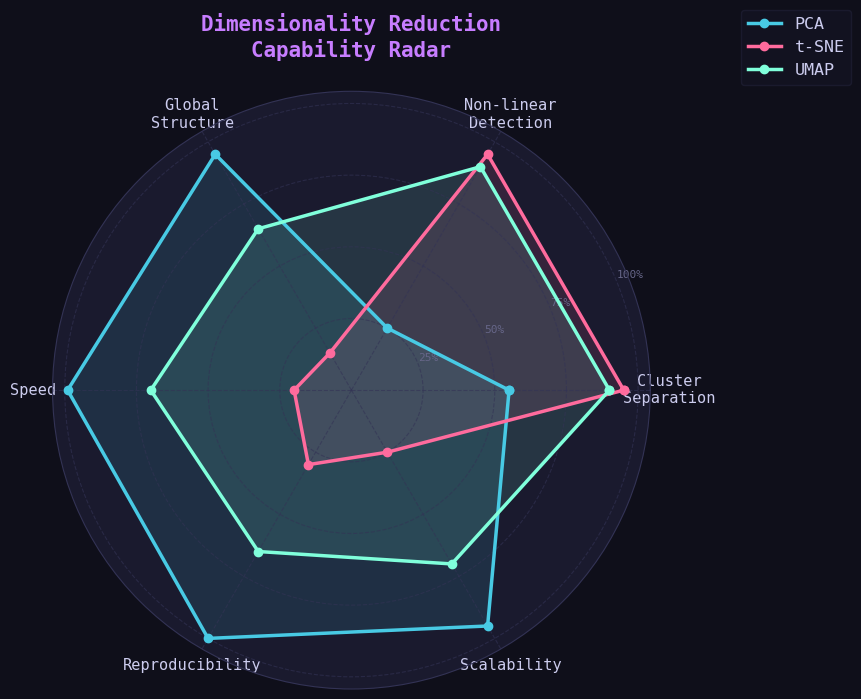


🏁 Notebook complete! t-SNE is powerful but must be used with care.
   The key insight: it reveals LOCAL structure brilliantly, but GLOBAL structure is lost.


In [13]:
# Summary scorecard visualisation
categories = ['Cluster\nSeparation', 'Non-linear\nDetection', 'Global\nStructure', 
               'Speed', 'Reproducibility', 'Scalability']
pca_scores   = [0.55, 0.25, 0.95, 0.99, 1.0, 0.95]
tsne_scores  = [0.95, 0.95, 0.15, 0.20, 0.30, 0.25]
umap_scores  = [0.90, 0.90, 0.65, 0.70, 0.65, 0.70]

angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

for scores, label, color in [
    (pca_scores,  'PCA',   '#48cae4'),
    (tsne_scores, 't-SNE', '#ff6b9d'),
    (umap_scores, 'UMAP',  '#80ffdb'),
]:
    vals = scores + scores[:1]
    ax.plot(angles, vals, 'o-', lw=2.5, color=color, label=label)
    ax.fill(angles, vals, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11, color='#ccccee')
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], color='#666688', size=8)
ax.yaxis.grid(True, color='#333355', alpha=0.6)
ax.xaxis.grid(True, color='#333355', alpha=0.6)
ax.spines['polar'].set_color('#333355')

ax.set_title('Dimensionality Reduction\nCapability Radar', 
             size=15, fontweight='bold', color='#c77dff', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
          framealpha=0.3, facecolor='#1a1a2e', edgecolor='#333355',
          fontsize=12)

plt.tight_layout()
plt.show()
print('\n🏁 Notebook complete! t-SNE is powerful but must be used with care.')
print('   The key insight: it reveals LOCAL structure brilliantly, but GLOBAL structure is lost.')